In [257]:
import pandas as pd

In [258]:
from sklearn.datasets import make_classification

## Creating Dataset

In [259]:
X,y = make_classification(n_samples = 1000,n_features = 10,n_classes = 2,random_state = 1)

In [260]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,-2.101187,-0.247208,-1.989335,-1.484556,1.128668,-0.925564,1.210290,2.070526,0.091527,-2.376400
1,0.323703,-0.126894,-1.309524,-0.022738,-0.398725,0.280419,0.034598,1.184820,-0.186802,1.969326
2,2.232038,0.334123,-0.852703,3.289016,0.331944,0.044767,-2.233844,-0.066448,-0.313881,1.499174
3,-0.428456,1.627132,0.484649,0.938373,1.339947,-0.869036,0.943132,0.713558,-0.468041,0.075341
4,0.386012,0.338141,-0.186530,2.369137,1.667284,-0.979107,0.951526,0.398790,0.729005,0.372213
...,...,...,...,...,...,...,...,...,...,...
995,-1.148812,-0.048464,0.555170,-2.167311,-0.595136,0.237045,-1.241394,-0.144619,-0.136638,-1.363868
996,1.585814,1.269868,1.193456,2.321360,0.222056,0.040255,2.260748,-0.182916,-0.959332,0.263967
997,-1.169663,0.230641,-2.710394,-3.217224,-1.509607,0.795293,-0.854581,0.021500,-1.066801,0.528868
998,-2.646182,-0.117844,0.149377,-0.377960,2.755272,-1.983281,-1.865016,0.340473,-0.276940,-0.871014


In [261]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = .25, random_state = 42)

In [262]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

## Evaluation

In [263]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)
cm = confusion_matrix(y_test, y_pred)
print(cm)
cr = classification_report(y_test, y_pred)
print(cr)

0.86
[[108  19]
 [ 16 107]]
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       127
           1       0.85      0.87      0.86       123

    accuracy                           0.86       250
   macro avg       0.86      0.86      0.86       250
weighted avg       0.86      0.86      0.86       250



## Hyper parameter tuning for best model performance 

In [264]:
model = LogisticRegression()
params = { #* Key : Value Pairs
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [100, 10, 1.0, 0.1, 0.01],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}
from sklearn.model_selection import StratifiedGroupKFold
cv = StratifiedGroupKFold()
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=params,scoring='accuracy', cv=5, n_jobs = -1)

In [265]:
grid

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [266]:
grid.fit(X_train, y_train)

e:\Machine_Learning\myenv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
200 fits failed out of a total of 375.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "e:\Machine_Learning\myenv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Machine_Learning\myenv\Lib\site-packages\sklearn\base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "e:\Machine_Learning\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1210, in fit
    solv

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [267]:
grid.best_params_

{'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}

In [268]:
grid.best_score_

np.float64(0.8520000000000001)

In [269]:
y_pred = grid.predict(X_test)

In [270]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)
cm = confusion_matrix(y_test, y_pred)
print(cm)
cr = classification_report(y_test, y_pred)
print(cr)

0.868
[[108  19]
 [ 14 109]]
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       127
           1       0.85      0.89      0.87       123

    accuracy                           0.87       250
   macro avg       0.87      0.87      0.87       250
weighted avg       0.87      0.87      0.87       250



## Prediction Visualization

Visual checks for model quality:
- Confusion matrix heatmap
- ROC curve (AUC)
- Predicted probability distribution by class

In [271]:
from sklearn.metrics import roc_curve 
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot

In [272]:
dummy = [0 for _ in range (len(y_test))]
dummy

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [273]:
model = LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [274]:
#* Positive outcome (1)
model_prob = model.predict_proba(X_test)[:,1]

In [275]:
model_prob

array([2.38001479e-01, 9.50392553e-01, 6.29403648e-01, 9.98393363e-01,
       8.46999948e-01, 7.32799198e-02, 4.30517111e-01, 8.39553363e-01,
       5.07700978e-02, 1.30897915e-02, 8.60003071e-01, 4.25819459e-02,
       9.23824991e-01, 8.43699935e-01, 7.80003542e-02, 7.69767221e-02,
       8.13094236e-01, 1.38629346e-02, 6.11879126e-02, 9.92983641e-01,
       7.98343827e-01, 8.90093820e-01, 2.40335001e-01, 7.01579119e-01,
       3.04087645e-02, 2.72212884e-01, 1.90395439e-02, 7.51377934e-01,
       2.05202364e-01, 7.02317608e-01, 8.61998537e-01, 9.67062498e-01,
       9.39021490e-04, 8.00611511e-01, 9.71613468e-01, 8.76611169e-01,
       1.38039999e-03, 3.59258298e-02, 9.42180314e-01, 7.78192134e-01,
       9.88431417e-03, 9.95830269e-01, 6.64231995e-01, 3.47836821e-02,
       9.58583323e-01, 2.92690219e-02, 9.66098006e-02, 9.91643799e-01,
       4.61986456e-02, 8.57615624e-01, 9.88042291e-01, 4.29703058e-01,
       1.83935398e-01, 2.33505181e-01, 3.10092359e-01, 1.87541642e-02,
      

In [276]:
dummy_auc = roc_auc_score(y_test, dummy) #* compares 2 values and gives a value 
model_auc = roc_auc_score(y_test, model_prob)
print(dummy_auc)
print(model_auc)

0.5
0.922092055566225


# Calculate Roc curve 

In [277]:
dummy_frp, dummy_tpr, _ = roc_curve(y_test, dummy)
model_fpr, model_tpr, _ = roc_curve(y_test, model_prob)

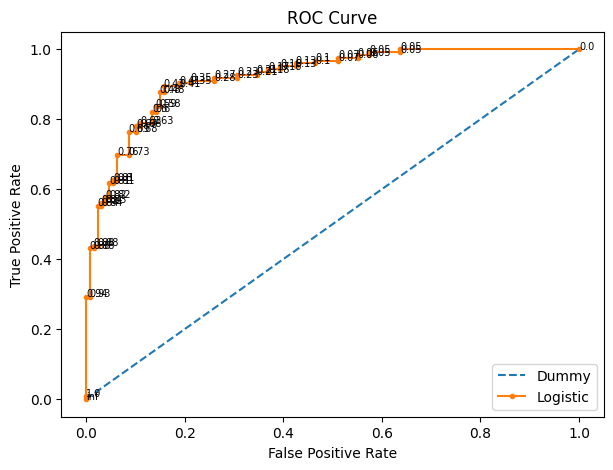

In [279]:
import numpy as np

# get thresholds for annotation
_, _, thresholds = roc_curve(y_test, model_prob)

fig, ax = pyplot.subplots(figsize=(7, 5))
ax.plot(dummy_frp, dummy_tpr, linestyle='--', label='Dummy')
ax.plot(model_fpr, model_tpr, marker='.', label='Logistic')

for fpr, tpr, thr in zip(model_fpr, model_tpr, thresholds):
    ax.annotate(f"{np.round(thr, 2)}", xy=(fpr, tpr), fontsize=7)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
pyplot.show()